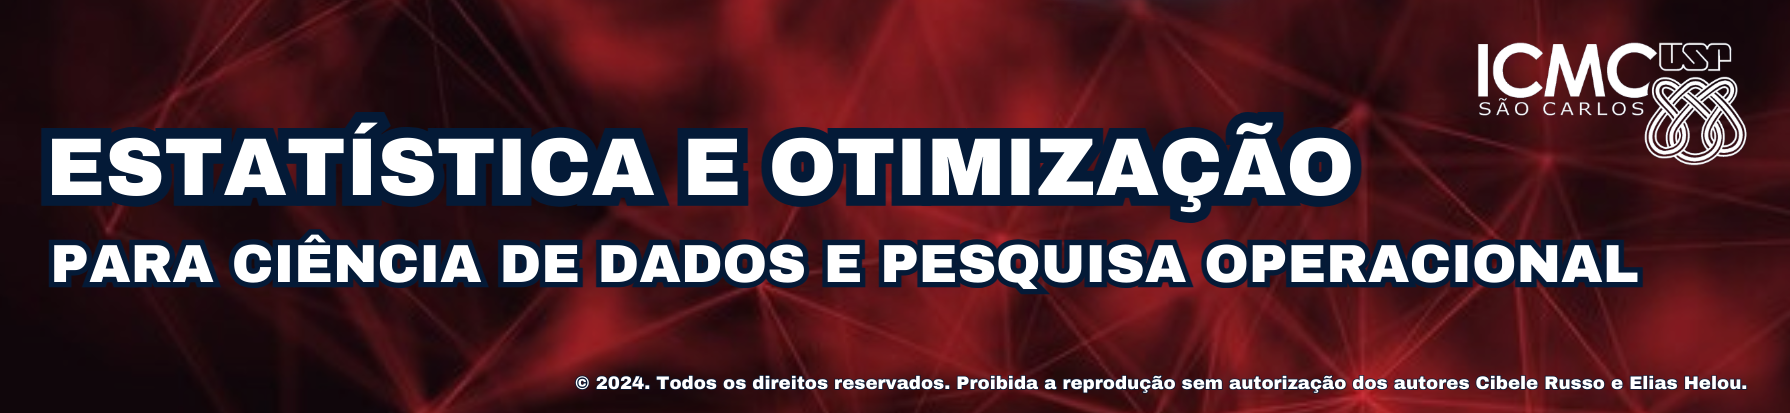

# Probabilidades - Parte 2

# Modelos probabilísticos discretos e contínuos


por **Cibele Russo**

**ICMC/USP - São Carlos SP**

Referências:

- MAGALHÃES, M. N.; LIMA, A. C. P.. Noções de probabilidade e estatística. São Paulo, SP, Brazil: Edusp, 2023. https://www.ime.usp.br/~noproest/doku.php

- BUSSAB, W. O.; MORETTIN, P. A. Estatística básica. 10. edição. Editora Saraiva. 2024.


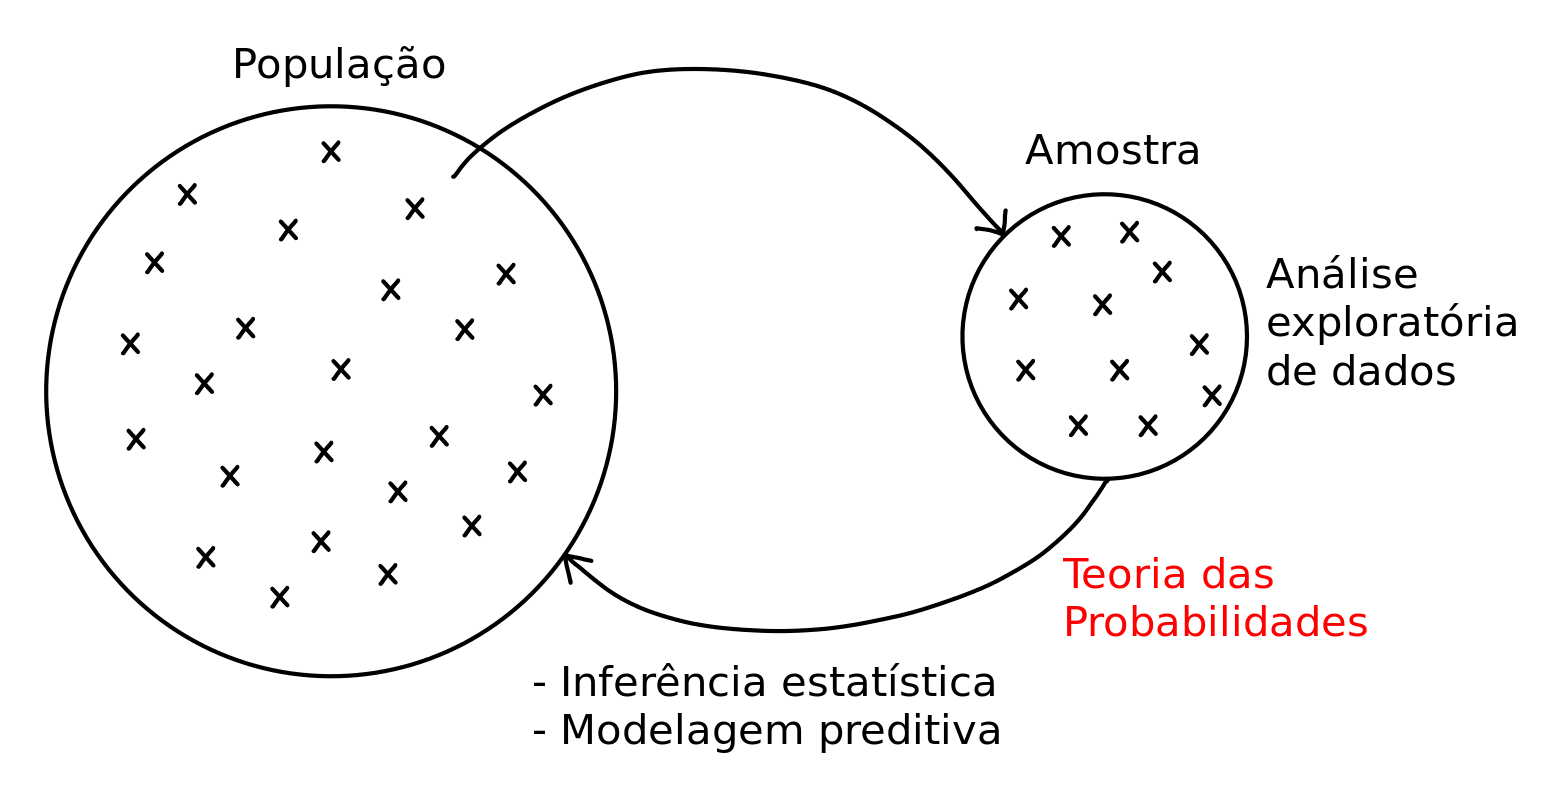

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore") # Ignorar todos os warnings

from scipy.stats import bernoulli, binom, poisson, uniform, norm, expon, t, f, chi2

# Modelos probabilísticos discretos

## Bernoulli

- Modelo para experimentos com dois possíveis resultados: sucesso (1) e fracasso (0).
- Parâmetro: $p$ (probabilidade de sucesso).
- Variável aleatória X assume 1, se sucesso, ou 0, se fracasso.
- Função massa de probabilidade: $P(X=x) = p^x (1 - p)^{1 - x}$, onde $x \in \{0,1\}$.





Média: 0.3, Variância: 0.21, Assimetria: 0.8728715609439694, Curtose: -1.2380952380952381


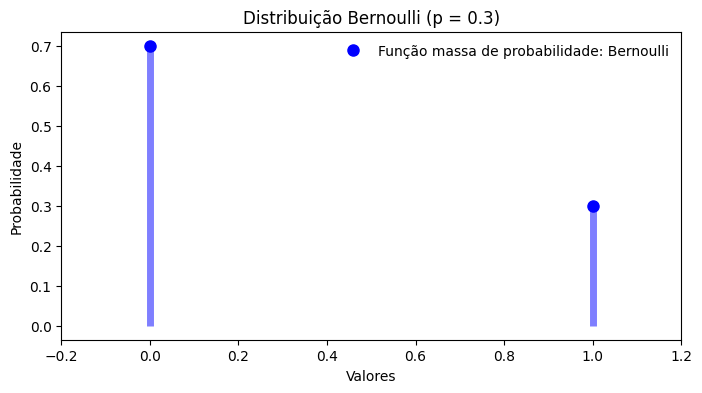

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bernoulli

# Parâmetro da distribuição Bernoulli
p = 0.3  # Probabilidade de sucesso

# Valores de x (0 e 1)
x = [0, 1]

# Calcula a função massa de probabilidade (PMF) para os valores de x
pmf_values = bernoulli.pmf(x, p)

# Exibe a PMF em um gráfico de barras
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

# Função de probabilidade
ax.plot(x, pmf_values, 'bo', ms=8, label='Função massa de probabilidade: Bernoulli')
ax.vlines(x, 0, pmf_values, colors='b', lw=5, alpha=0.5)

# Características do modelo
mean, var, skew, kurt = bernoulli.stats(p, moments='mvsk')
print(f'Média: {mean}, Variância: {var}, Assimetria: {skew}, Curtose: {kurt}')

# Configurações do gráfico
ax.legend(loc='best', frameon=False)
plt.xlim([-0.2, 1.2])
plt.title("Distribuição Bernoulli (p = 0.3)")
plt.xlabel("Valores")
plt.ylabel("Probabilidade")
plt.show()


##### Exemplo Bernoulli

Suponha que uma empresa esteja testando se um novo design de embalagem aumenta a taxa de compra de um produto. Cada cliente que vê a nova embalagem pode comprá-lo (sucesso) ou não comprá-lo (fracasso). Se a probabilidade de compra for de 30% (p=0.3), podemos modelar esse evento como uma variável de Bernoulli.

In [53]:
# Probabilidade de sucesso (compra do produto)
p = 0.3

# Probabilidades dos dois possíveis resultados
prob_sucesso = bernoulli.pmf(1, p)  # P(X=1)
prob_fracasso = bernoulli.pmf(0, p)  # P(X=0)

print(f"Probabilidade de um cliente comprar o produto: {prob_sucesso:.2f}")
print(f"Probabilidade de um cliente não comprar o produto: {prob_fracasso:.2f}")


Probabilidade de um cliente comprar o produto: 0.30
Probabilidade de um cliente não comprar o produto: 0.70


## Binomial


- Representa o número de sucessos em $n$ tentativas independentes de um experimento de Bernoulli.
- Parâmetros: $n$ (número de tentativas) e $p$ (probabilidade de sucesso em cada tentativa).
- A variável aleatória X assume valores 0, 1, 2, ..., n.
- Função de probabilidade: $P(X=k) = \displaystyle\binom{n}{k} p^k (1 - p)^{n - k}$, onde $k = 0,1,\dots,n$.


Média: 3.0, Variância: 2.1, Assimetria: 0.27602622373694163, Curtose: -0.12380952380952381


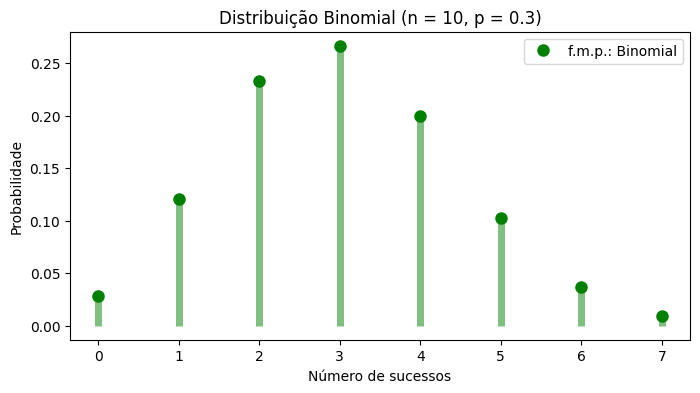

In [54]:
from scipy.stats import binom

# Parâmetros da distribuição binomial
n, p = 10, 0.3

# Características do modelo
mean, var, skew, kurt = binom.stats(n, p, moments='mvsk')
print(f'Média: {mean}, Variância: {var}, Assimetria: {skew}, Curtose: {kurt}')


# Função de massa de probabilidade (pmf)
x = np.arange(binom.ppf(0.001, n, p), binom.ppf(0.999, n, p))
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(x, binom.pmf(x, n, p), 'go', ms=8, label='f.m.p.: Binomial')
ax.vlines(x, 0, binom.pmf(x, n, p), colors='g', lw=5, alpha=0.5)
ax.set_title("Distribuição Binomial (n = 10, p = 0.3)")
ax.set_xlabel("Número de sucessos")
ax.set_ylabel("Probabilidade")
ax.legend()
plt.show()


In [55]:
0.7**10

0.028247524899999984

In [56]:
10*0.3**1*0.7**9

0.12106082099999993

##### Exemplo

No exemplo anterior (Bernoulli), calcule a probabilidade de exatamente 3 clientes comprarem o produto entre 10 clientes diferentes.

In [57]:
# Probabilidade de sucesso (compra do produto)
p = 0.3

# Número de tentativas (clientes que veem a embalagem)
n = 10

k=3
prob_k_sucessos = binom.pmf(k, n, p)
print(f"Probabilidade de exatamente {k} clientes comprarem o produto em {n} tentativas: {prob_k_sucessos:.4f}")


Probabilidade de exatamente 3 clientes comprarem o produto em 10 tentativas: 0.2668


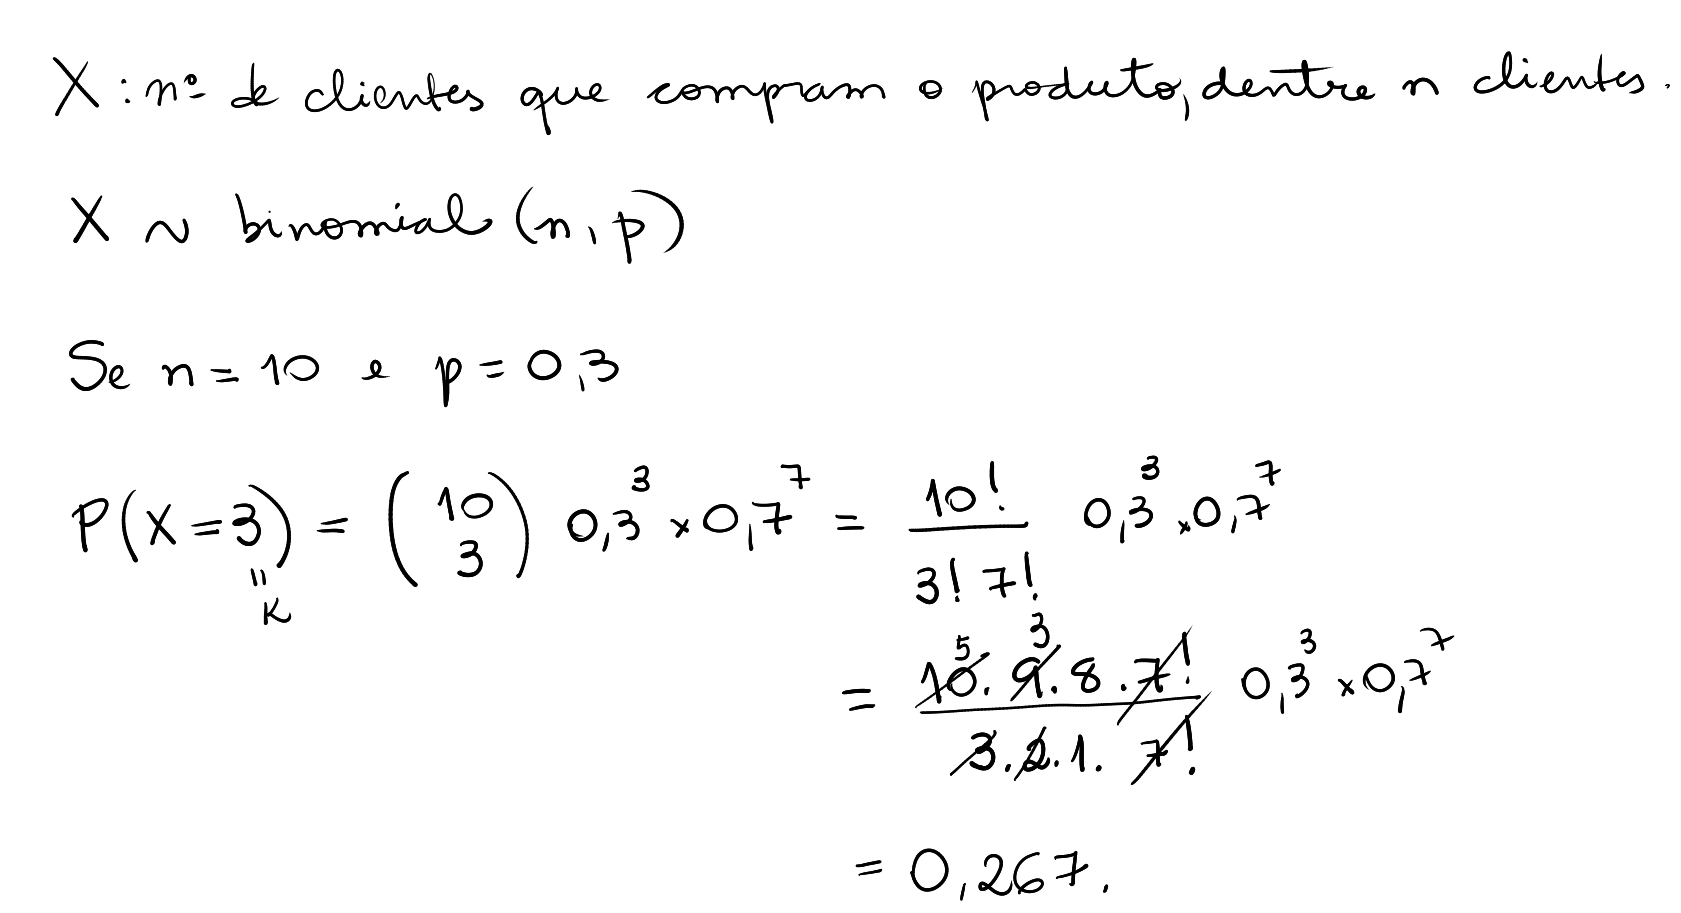

## Poisson

- Modela o número de ocorrências de um evento em um intervalo fixo de tempo ou espaço.
- Parâmetro: $\lambda$ (número médio de ocorrências).
- Função de probabilidade: $P(X=k) = \displaystyle \frac{e^{-\lambda}\lambda^k }{k!}$, onde $k = 0,1,2,\dots$


Média: 3.0, Variância: 3.0, Assimetria: 0.5773502691896257, Curtose: 0.3333333333333333


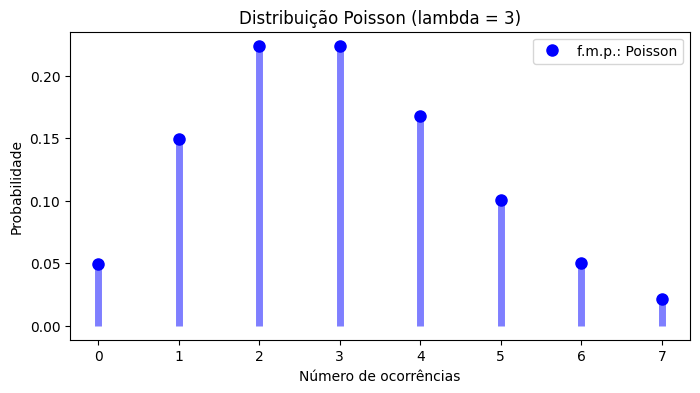

In [58]:
# Distribuição Poisson

# Parâmetro médio da distribuição
lambda_ = 3

# Características do modelo
mean, var, skew, kurt = poisson.stats(lambda_, moments='mvsk')
print(f'Média: {mean}, Variância: {var}, Assimetria: {skew}, Curtose: {kurt}')

# Função de massa de probabilidade (pmf)
x = np.arange(poisson.ppf(0.01, lambda_), poisson.ppf(0.99, lambda_))
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(x, poisson.pmf(x, lambda_), 'bo', ms=8, label='f.m.p.: Poisson')
ax.vlines(x, 0, poisson.pmf(x, lambda_), colors='b', lw=5, alpha=0.5)
ax.set_title("Distribuição Poisson (lambda = 3)")
ax.set_xlabel("Número de ocorrências")
ax.set_ylabel("Probabilidade")
ax.legend()
plt.show()

##### Exemplo:

Considere que em uma central de chamados técnicos, contamos o número de chamados recebidas por hora, e que a taxa média de 5 chamados por hora.

Calcule a probabilidade de chegarem exatamente 7 chamados em uma hora.

E de chegarem pelo menos 6 chamados em uma hora?

In [59]:
# Taxa média de ocorrências por hora
lambda_ = 5  # Em média, 5 chamados por hora

# Probabilidade de exatamente 7 chamados em uma hora
prob_7_chamados = poisson.pmf(7, lambda_)
print(f"Probabilidade de exatamente 7 chamados em uma hora: {prob_7_chamados:.4f}")

# Probabilidade de pelo menos 6 chamados em uma hora
prob_pelo_menos_6 = 1 - poisson.cdf(5, lambda_)
print(f"Probabilidade de pelo menos 6 chamados em uma hora: {prob_pelo_menos_6:.4f}")


Probabilidade de exatamente 7 chamados em uma hora: 0.1044
Probabilidade de pelo menos 6 chamados em uma hora: 0.3840


## Propriedades: modelos discretos

| Distribuição | Média (𝜇) | Variância (𝜎²) |
|-------------|----------|----------------|
| Bernoulli  | p        | p(1 - p)       |
| Binomial   | np       | np(1 - p)      |
| Poisson    | $\lambda$ | $\lambda$ |

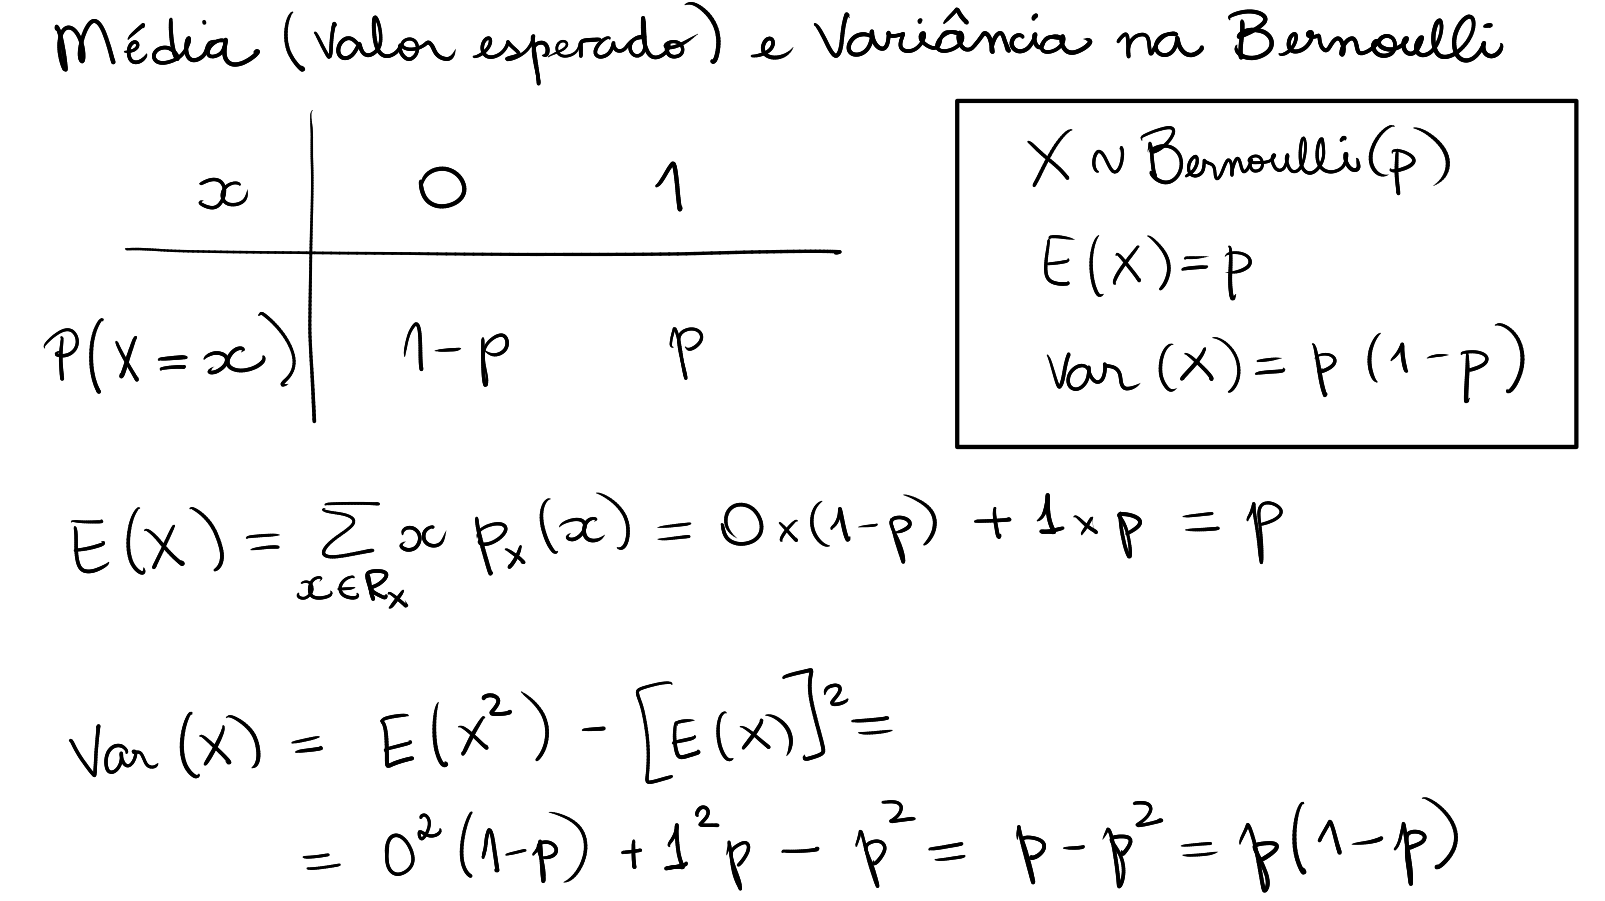


Outros modelos discretos:

- Geométrica: https://pt.wikipedia.org/wiki/Distribui%C3%A7%C3%A3o_geom%C3%A9trica
- Hipergeométrica: https://pt.wikipedia.org/wiki/Distribui%C3%A7%C3%A3o_hipergeom%C3%A9trica

# Modelos probabilísticos contínuos


## Uniforme


- Todos os intervalos de mesmo tamanho em $[a, b]$ têm a mesma probabilidade de ocorrer.
- Parâmetros: $a$ (mínimo) e $b$ (máximo).
- Função de densidade: $f(x) = \displaystyle \frac{1}{b - a}$, para $a \leq x \leq b$.



Média: 0.5, Variância: 0.08333333333333333, Assimetria: 0.0, Curtose: -1.2


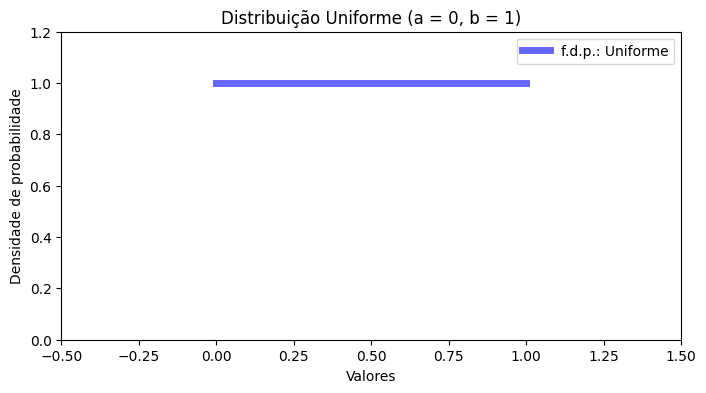

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

# Parâmetros da distribuição uniforme
loc = 0  # limite inferior
scale = 1  # limite superior - loc + scale = 1

# Características do modelo
mean, var, skew, kurt = uniform.stats(loc,scale, moments='mvsk')
print(f'Média: {mean}, Variância: {var}, Assimetria: {skew}, Curtose: {kurt}')

# Função de densidade de probabilidade (pdf)
x = np.linspace(loc, loc + scale, 100)
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(x, uniform.pdf(x, loc, scale), 'b-', lw=5, alpha=0.6, label='f.d.p.: Uniforme')
ax.set_title("Distribuição Uniforme (a = 0, b = 1)")
ax.set_xlabel("Valores")
ax.set_ylabel("Densidade de probabilidade")
ax.set_xlim([-0.5, 1.5])
ax.set_ylim([0, 1.2])
ax.legend()
plt.show()


##### Exemplo

Uma máquina de produção automática fabrica peças metálicas, e o tempo necessário para produzir cada peça é distribuído uniformemente entre 0 e 1 minuto. Qual a probabilidade de levar no mínimo 0,5 minuto para produzir uma peça?



In [61]:
# Distribuição Uniforme (0,1) - Tempo de produção de peças
min_tempo = 0  # Tempo mínimo
max_tempo = 1  # Tempo máximo

# Probabilidade de levar no mínimo 0,5 minuto para produzir uma peça
prob_minimo_meio_minuto = 1 - uniform.cdf(0.5, min_tempo, max_tempo - min_tempo)
print(f"Probabilidade de levar no mínimo 0,5 minuto para produzir uma peça: {prob_minimo_meio_minuto:.4f}")

Probabilidade de levar no mínimo 0,5 minuto para produzir uma peça: 0.5000


## Normal


- É o modelo probabilístico mais importante. Modela muitos fenômenos naturais e sociais.
- Parâmetros: $\mu$ (média) e $\sigma$ (desvio padrão).
- Função de densidade: $f(x) = \displaystyle \frac{1}{\sqrt{2 \pi\sigma^2 }} exp\left\{-\displaystyle \frac{(x - \mu)^2}{2 \sigma^2}\right\}$.


Média: 0.0, Variância: 1.0, Assimetria: 0.0, Curtose: 0.0


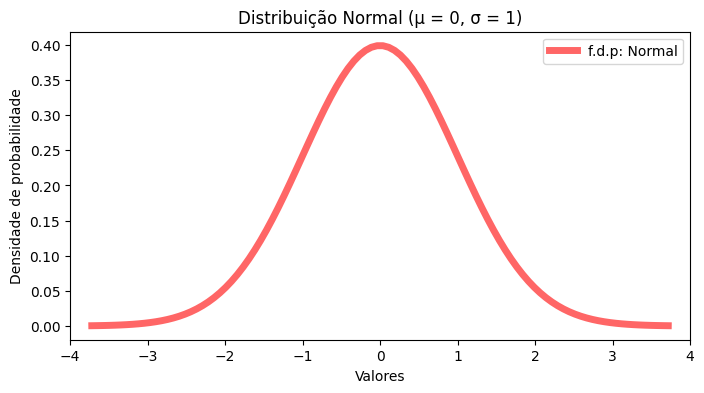

In [62]:
# Distribuição Normal

from scipy.stats import norm

# Características do modelo
mean, var, skew, kurt = norm.stats(moments='mvsk')
print(f'Média: {mean}, Variância: {var}, Assimetria: {skew}, Curtose: {kurt}')

# Exibir a função de densidade de probabilidade (pdf)
x = np.linspace(norm.ppf(0.0001), norm.ppf(0.9999), 100)
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(x, norm.pdf(x), 'r-', lw=5, alpha=0.6, label='f.d.p: Normal')
ax.set_title("Distribuição Normal (μ = 0, σ = 1)")
ax.set_xlabel("Valores")
ax.set_ylabel("Densidade de probabilidade")
ax.set_xlim([-4, 4])
ax.legend()
plt.show()

##### Exemplo

Sabe-se que a altura das brasileiras segue uma distribuição normal com média de 1,61m e desvio padrão de 0,07m.

Qual a probabilidade de uma brasileira selecionada ao acaso ter mais de 1,70m de altura? E mais de 1,80m de altura?


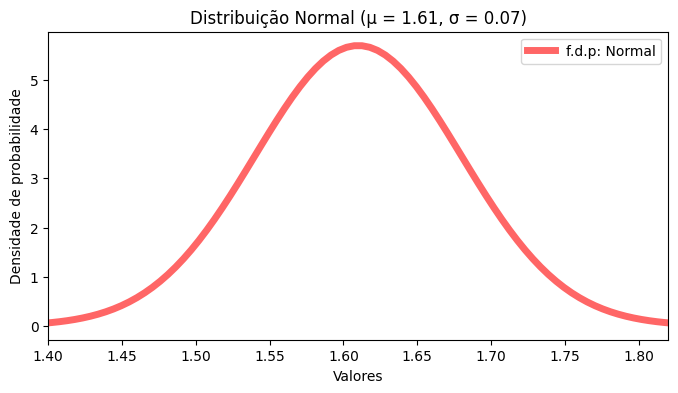

In [63]:
# Distribuição Normal

from scipy.stats import norm

# Exibir a função de densidade de probabilidade (pdf)
x = np.linspace(norm.ppf(0.0001, 1.61, 0.07), norm.ppf(0.9999, 1.61, 0.07), 100)
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(x, norm.pdf(x, 1.61, 0.07), 'r-', lw=5, alpha=0.6, label='f.d.p: Normal')
ax.set_title("Distribuição Normal (μ = 1.61, σ = 0.07)")
ax.set_xlabel("Valores")
ax.set_ylabel("Densidade de probabilidade")
ax.set_xlim([1.4, 1.82])
ax.legend()
plt.show()

In [64]:
# Distribuição Normal - Altura das brasileiras
media_altura = 1.61  # Média em metros
desvio_padrao_altura = 0.07  # Desvio padrão em metros

# Probabilidade de uma brasileira ter mais de 1,70 m
prob_mais_170 = 1 - norm.cdf(1.70, media_altura, desvio_padrao_altura)
print(f"Probabilidade de uma brasileira ter mais de 1,70 m: {prob_mais_170:.4f}")


# Probabilidade de uma brasileira ter mais de 1,80 m
prob_mais_180 = 1 - norm.cdf(1.80, media_altura, desvio_padrao_altura)
print(f"Probabilidade de uma brasileira ter mais de 1,80 m: {prob_mais_180:.4f}")

Probabilidade de uma brasileira ter mais de 1,70 m: 0.0993
Probabilidade de uma brasileira ter mais de 1,80 m: 0.0033


### Propriedades da Distribuição Normal

A distribuição normal é o modelo probabilístico mais importante, por isso estudamos com mais detalhes suas propriedades.

#### Soma de Normais
Se $X_1 \sim \mathcal{N}(\mu_1, \sigma_1^2)$ e $X_2 \sim \mathcal{N}(\mu_2, \sigma_2^2)$ são variáveis aleatórias normais independentes, então sua soma também segue uma distribuição normal:
$$X_1 + X_2 \sim \mathcal{N}(\mu_1 + \mu_2, \sigma_1^2 + \sigma_2^2).$$

#### Transformação Afim de uma Normal
Se $X \sim \mathcal{N}(\mu, \sigma^2)$ e realizamos a transformação afim $$Y = aX + b,$$ onde $a, b \in \mathbb{R}$ e $a \neq 0$, então $Y$ também segue uma distribuição normal:
$$Y \sim \mathcal{N}(a\mu + b, a^2\sigma^2).$$

#### Padronização pela Normal Padrão
Dada uma variável aleatória $X \sim \mathcal{N}(\mu, \sigma^2)$, podemos padronizá-la subtraindo a média e dividindo pelo desvio padrão:

$$Z = \frac{X - \mu}{\sigma}.$$

A variável $Z$ segue uma distribuição normal padrão:

$$Z \sim \mathcal{N}(0,1).$$


##### Exemplo:

Um elevador suporta 450kg, e a recomendação é que transporte, no máximo, 6 pessoas por vez.

Considere que o peso médio de uma pessoa seja 70kg com desvio-padrão 10kg.

Calcule a probabilidade de 6 pessoas excederem os 450 kg.

E de 5 pessoas excederem os 450 kg.

In [65]:
# Distribuição Normal Padrão - Peso no elevador
peso_medio = 70  # Média de peso por pessoa (kg)
desvio_padrao_peso = 10  # Desvio padrão do peso (kg)
peso_maximo = 450  # Capacidade máxima do elevador (kg)

# Média e desvio padrão do peso total
n_pessoas = 6 # Número de pessoas no elevador
media_peso_total = n_pessoas * peso_medio
desvio_peso_total = np.sqrt(n_pessoas) * desvio_padrao_peso

# Probabilidade de o peso total exceder 420 kg
prob_exceder_peso = 1 - norm.cdf(peso_maximo, media_peso_total, desvio_peso_total)
print(f"Probabilidade de o elevador exceder o peso máximo de 450 kg com 6 pessoas: {prob_exceder_peso:.4f}")

# Média e desvio padrão do peso total
n_pessoas = 5 # Número de pessoas no elevador

media_peso_total = n_pessoas * peso_medio
desvio_peso_total = np.sqrt(n_pessoas) * desvio_padrao_peso

# Probabilidade de o peso total exceder 420 kg
prob_exceder_peso = 1 - norm.cdf(peso_maximo, media_peso_total, desvio_peso_total)
print(f"Probabilidade de o elevador exceder o peso máximo de 450 kg com 5 pessoas: {prob_exceder_peso:.4f}")


Probabilidade de o elevador exceder o peso máximo de 450 kg com 6 pessoas: 0.1103
Probabilidade de o elevador exceder o peso máximo de 450 kg com 5 pessoas: 0.0000


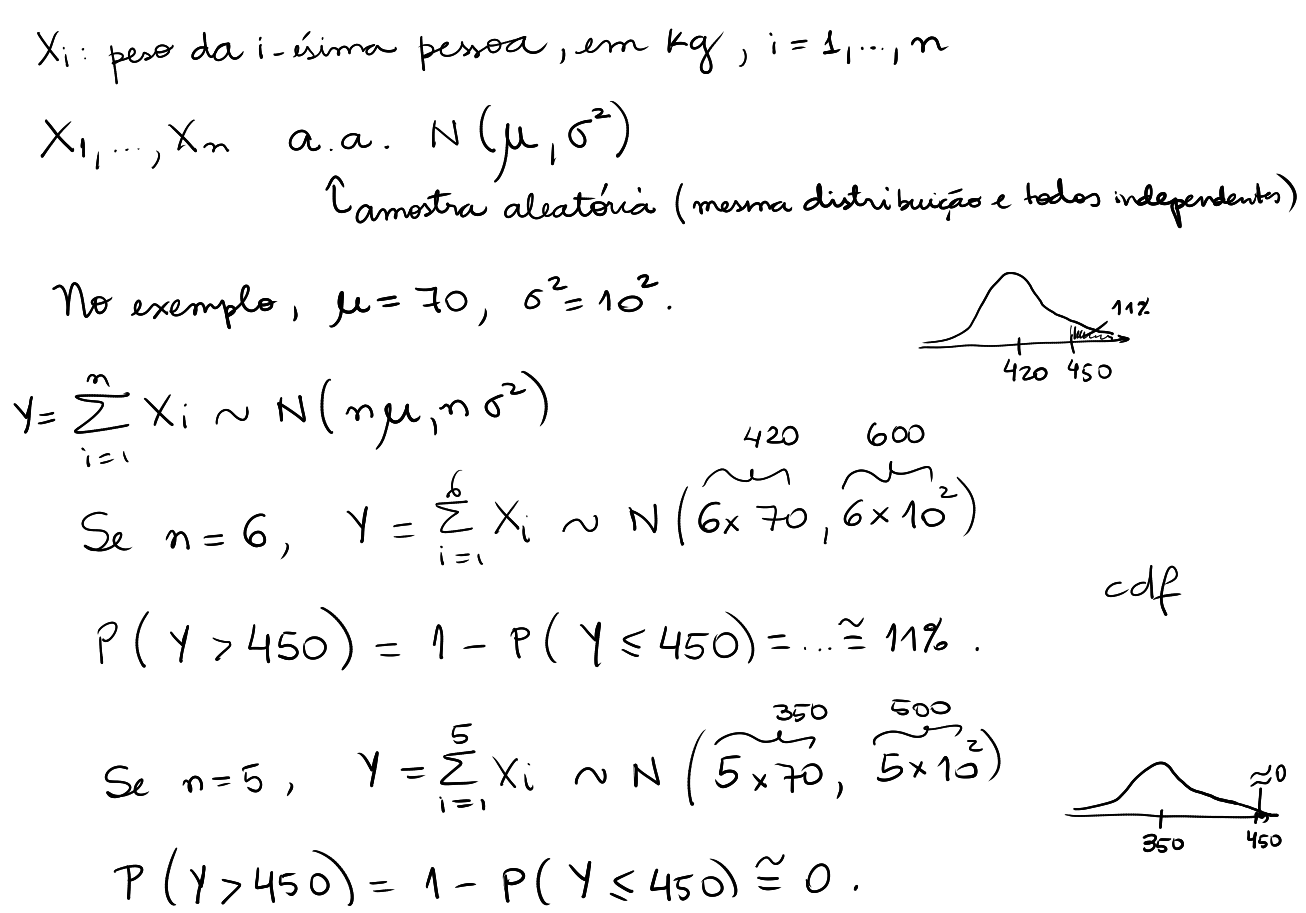

## Exponencial


- Modela o tempo entre ocorrências de eventos em um processo de Poisson.
- Parâmetro: $\lambda$ (taxa de ocorrência).
- Função de densidade: $f(x) = \lambda e^{-\lambda x}$, para $x \geq 0$.



Média: 1.0, Variância: 1.0, Assimetria: 2.0, Curtose: 6.0


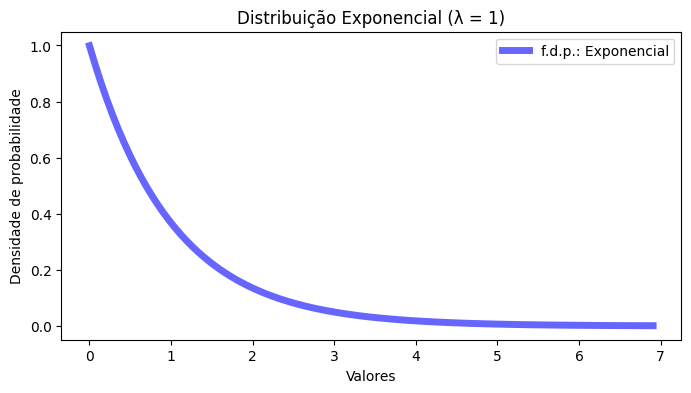

In [66]:
# Distribuição Exponencial

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import expon

# Parâmetro da distribuição exponencial
lambda_exp = 1  # Taxa de ocorrência

# Características do modelo
mean, var, skew, kurt = expon.stats(scale=1/lambda_exp, moments='mvsk')
print(f'Média: {mean}, Variância: {var}, Assimetria: {skew}, Curtose: {kurt}')

# Exibir a função de densidade de probabilidade (pdf)
x = np.linspace(expon.ppf(0.001, scale=1/lambda_exp), expon.ppf(0.999, scale=1/lambda_exp), 100)
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(x, expon.pdf(x, scale=1/lambda_exp), 'b-', lw=5, alpha=0.6, label='f.d.p.: Exponencial')
ax.set_title("Distribuição Exponencial (λ = 1)")
ax.set_xlabel("Valores")
ax.set_ylabel("Densidade de probabilidade")
ax.legend()
plt.show()

##### Exemplo

O tempo de vida de uma geladeira segue uma distribuição exponencial com média de 10 anos e
desvio padrão de 2 anos.

Qual a probabilidade de uma geladeira durar mais de 12 anos?
Qual a probabilidade de uma geladeira apresentar falha antes dos 8 anos?

In [67]:
# Distribuição Exponencial - Tempo de vida de geladeiras
media_vida = 10  # Média de vida útil em anos
lambda_vida = 1 / media_vida  # Taxa da distribuição exponencial

# Probabilidade de uma geladeira durar mais de 12 anos
prob_mais_12_anos = 1 - expon.cdf(12, scale=1/lambda_vida)
print(f"Probabilidade de uma geladeira durar mais de 12 anos: {prob_mais_12_anos:.4f}")

# Probabilidade de uma geladeira falhar antes dos 8 anos
prob_menos_8_anos = expon.cdf(8, scale=1/lambda_vida)
print(f"Probabilidade de uma geladeira falhar antes dos 8 anos: {prob_menos_8_anos:.4f}")

Probabilidade de uma geladeira durar mais de 12 anos: 0.3012
Probabilidade de uma geladeira falhar antes dos 8 anos: 0.5507


In [68]:

# Probabilidade de uma geladeira falhar antes dos 2 anos
prob_menos_2_anos = expon.cdf(2, scale=1/lambda_vida)
print(f"Probabilidade de uma geladeira falhar antes dos 2 anos: {prob_menos_2_anos:.4f}")

Probabilidade de uma geladeira falhar antes dos 2 anos: 0.1813


In [69]:

# Probabilidade de uma geladeira falhar antes de 1 ano
prob_menos_1_ano = expon.cdf(1, scale=1/lambda_vida)
print(f"Probabilidade de uma geladeira falhar antes de 1 ano: {prob_menos_1_ano:.4f}")

Probabilidade de uma geladeira falhar antes de 1 ano: 0.0952


## t-Student: Distribuição t de Student

- Usada em amostras pequenas para inferência sobre a média populacional.
- Parâmetro: graus de liberdade ($\nu$).
- Função de densidade: complexa, baseada na função gamma e nos graus de liberdade.




Média: 0.0, Variância: 1.25, Assimetria: 0.0, Curtose: 1.0


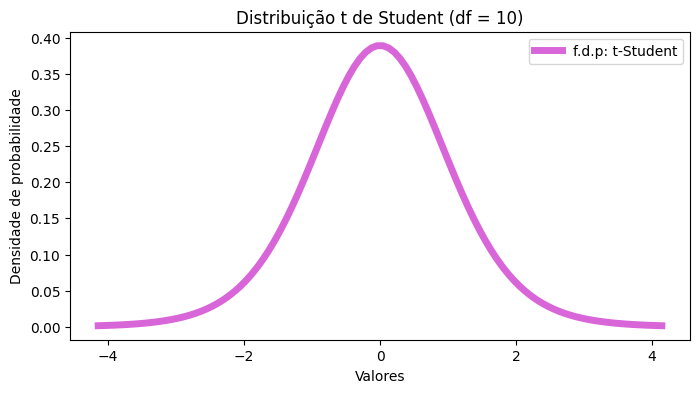

In [70]:
# Distribuição t de Student

from scipy.stats import t

# Parâmetros da distribuição t de Student
df = 10  # Graus de liberdade

# Características do modelo
mean, var, skew, kurt = t.stats(df, moments='mvsk')
print(f'Média: {mean}, Variância: {var}, Assimetria: {skew}, Curtose: {kurt}')


# Exibir a função de densidade de probabilidade (pdf)
x = np.linspace(t.ppf(0.001, df), t.ppf(0.999, df), 100)
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(x, t.pdf(x, df), 'm-', lw=5, alpha=0.6, label='f.d.p: t-Student')
ax.set_title("Distribuição t de Student (df = 10)")
ax.set_xlabel("Valores")
ax.set_ylabel("Densidade de probabilidade")
ax.legend()
plt.show()

## Qui-quadrado: Distribuição qui-quadrado  

- Usada para testar a variância de uma população e em testes de independência e aderência.  
- Parâmetro: graus de liberdade ($\nu$).  
- Função de densidade: envolve a função gamma e depende dos graus de liberdade.  
- A soma de $k$ variáveis independentes e normalmente distribuídas ao quadrado segue uma distribuição qui-quadrado com $k$ graus de liberdade.


Média: 0.0, Variância: 1.25, Assimetria: 0.0, Curtose: 1.0


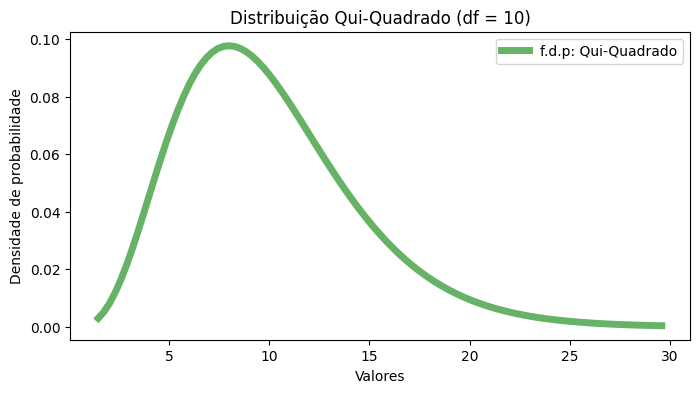

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Parâmetros da distribuição qui-quadrado
df = 10  # Graus de liberdade

# Características do modelo
mean, var, skew, kurt = t.stats(df, moments='mvsk')
print(f'Média: {mean}, Variância: {var}, Assimetria: {skew}, Curtose: {kurt}')


# Exibir a função de densidade de probabilidade (pdf)
x = np.linspace(chi2.ppf(0.001, df), chi2.ppf(0.999, df), 100)
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(x, chi2.pdf(x, df), 'g-', lw=5, alpha=0.6, label='f.d.p: Qui-Quadrado')
ax.set_title("Distribuição Qui-Quadrado (df = 10)")
ax.set_xlabel("Valores")
ax.set_ylabel("Densidade de probabilidade")
ax.legend()
plt.show()


## F de Fisher-Snedecor: Distribuição F  

- Usada para comparar variâncias de duas populações e em ANOVA.  
- Parâmetros: dois graus de liberdade ($\nu_1, \nu_2$).  
- Função de densidade: baseada na razão de duas variáveis qui-quadrado independentes normalizadas por seus respectivos graus de liberdade.  
- A razão entre duas variáveis qui-quadrado independentes, cada uma dividida por seus graus de liberdade, segue uma distribuição F.  


Média: 1.25, Variância: 1.3541666666666667, Assimetria: 3.867020319812938, Curtose: 50.86153846153847


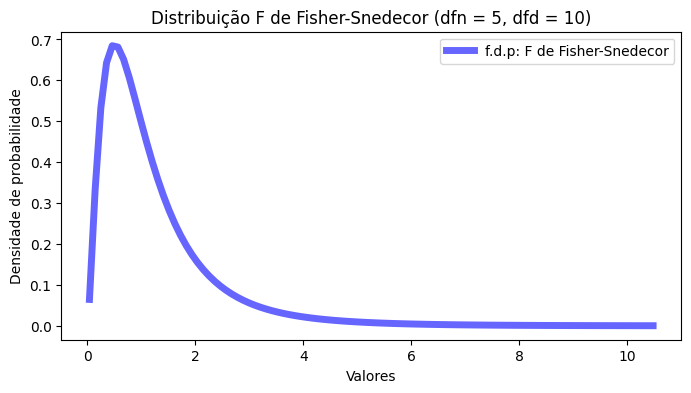

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f

# Parâmetros da distribuição F de Fisher-Snedecor
dfn = 5  # Graus de liberdade do numerador
dfd = 10  # Graus de liberdade do denominador

# Características do modelo
mean, var, skew, kurt = f.stats(dfn, dfd, moments='mvsk')
print(f'Média: {mean}, Variância: {var}, Assimetria: {skew}, Curtose: {kurt}')

# Exibir a função de densidade de probabilidade (pdf)
x = np.linspace(f.ppf(0.001, dfn, dfd), f.ppf(0.999, dfn, dfd), 100)
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(x, f.pdf(x, dfn, dfd), 'b-', lw=5, alpha=0.6, label='f.d.p: F de Fisher-Snedecor')
ax.set_title("Distribuição F de Fisher-Snedecor (dfn = 5, dfd = 10)")
ax.set_xlabel("Valores")
ax.set_ylabel("Densidade de probabilidade")
ax.legend()
plt.show()


## Propriedades: modelos contínuos

| Distribuição   | Média (𝜇)              | Variância (𝜎²)                        |
|---------------|----------------------|----------------------------------|
| Uniforme $U(a, b)$ | $\frac{a + b}{2}$ | $\frac{(b - a)^2}{12}$       |
| Normal $N(\mu, \sigma^2)$ | $\mu$ | $\sigma^2$ |
| Exponencial $Exp(\lambda)$ | $\frac{1}{\lambda}$ | $\frac{1}{\lambda^2}$ |
| t de Student ($t_\nu$) | $0$, se $\nu > 1$ | $\frac{\nu}{\nu - 2}$, se $\nu > 2$ |
| Qui-quadrado ($\chi^2_k$) | $k$ | $2k$ |
| F ($F_{d_1, d_2}$) | $\frac{d_2}{d_2 - 2}$, se $d_2 > 2$ | $\frac{2 d_2^2 (d_1 + d_2 - 2)}{d_1 (d_2 - 2)^2 (d_2 - 4)}$, se $d_2 > 4$ |


### Observações:

- A média da distribuição $t$ de Student só existe para $\nu > 1$.

- A variância da $t$ de Student só existe para $\nu > 2$.

- A média da distribuição $F$ só existe para $d_2 > 2$ e a variância para $d_2 > 4$.

# Teorema do Limite Central (TLC)


- O Teorema do Limite Central afirma que, para uma amostra suficientemente grande de variáveis aleatórias independentes e identicamente distribuídas, a distribuição da média (amostral) se aproxima de uma distribuição normal, independentemente da distribuição original das variáveis.


Formalizando: Se $X_1, X_2, \dots, X_n$ são variáveis aleatórias independentes, todas vindas da mesma distribuição, com média $\mu$ e variância $\sigma^2$ desconhecidas, então, para n suficientemente grande, $$\overline{X} = \displaystyle\frac{\displaystyle\sum_{i=1}^n X_i}{{n} } \approx \mathcal{N}\left(\mu, \displaystyle\frac{\sigma^2}{n}\right).$$


Outra forma de escrever:

Seja $X_1, X_2, \dots, X_n$ uma sequência de variáveis aleatórias independentes e identicamente distribuídas (i.i.d.), com média $\mu$ e variância finita $\sigma^2$. O Teorema do Limite Central afirma que a distribuição padronizada da soma dessas variáveis converge para uma distribuição normal quando $n \to \infty$:

$Z_n = \displaystyle\frac{\sum_{i=1}^{n} X_i - n\mu}{\sigma\sqrt{n}} \xrightarrow{d} \mathcal{N}(0,1)$

Ou equivalentemente, para a média amostral:

$\bar{X}_n = \displaystyle\frac{1}{n} \sum_{i=1}^{n} X_i$

tem distribuição aproximadamente normal para \( n \) suficientemente grande:

$\bar{X}_n \approx \mathcal{N} \left( \mu, \displaystyle\frac{\sigma^2}{n} \right).$

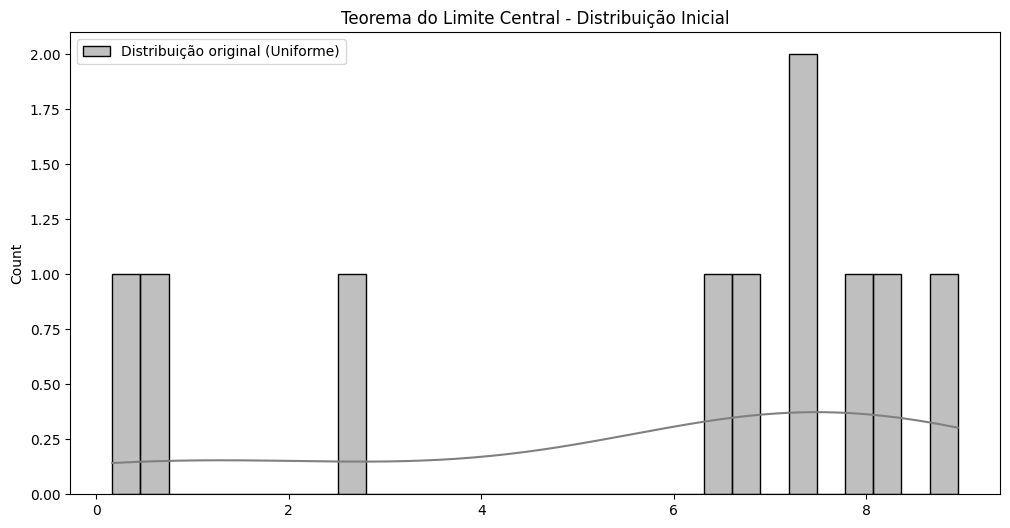

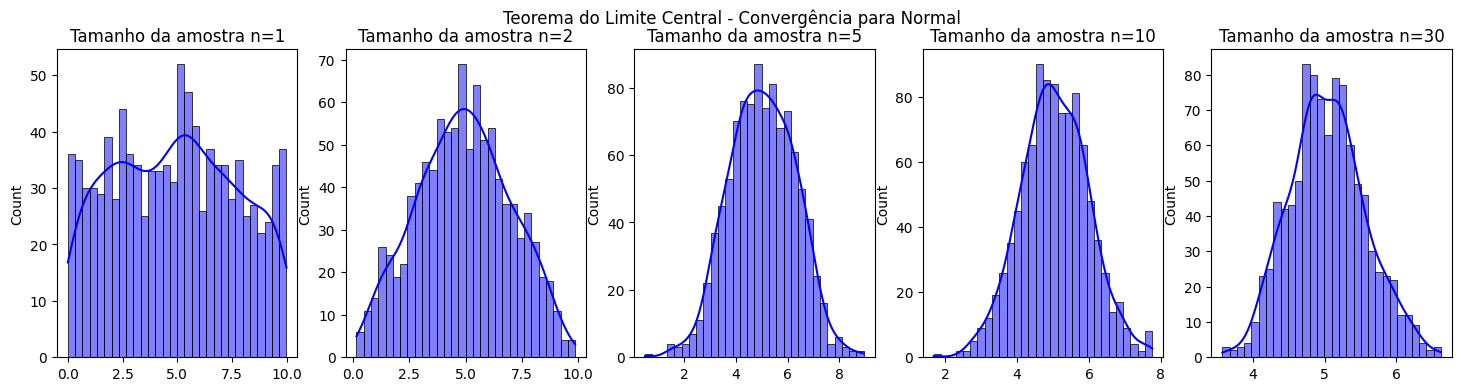

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore") # Ignorar todos os warnings

# Parâmetros
n_samples = [1, 2, 5, 10, 30]  # Tamanhos de amostra
n_replications = 1000  # Número de réplicas
sample_size = 10  # Número de observações por amostra

# Gerar dados da distribuição inicial (Uniforme)
original_data =  np.random.uniform(0, 10, sample_size)

# Plotar a distribuição original
plt.figure(figsize=(12, 6))
sns.histplot(original_data, bins=30, kde=True, color='gray', label="Distribuição original (Uniforme)")
plt.title("Teorema do Limite Central - Distribuição Inicial")
plt.legend()
plt.show()

# Plotar as distribuições da média amostral para diferentes tamanhos de amostra
fig, axes = plt.subplots(1, len(n_samples), figsize=(18, 4))
for i, n in enumerate(n_samples):
    means = np.mean(np.random.uniform(0, 10, (n_replications, n)), axis=1)
    sns.histplot(means, bins=30, kde=True, ax=axes[i], color='blue')
    axes[i].set_title(f"Tamanho da amostra n={n}")

plt.suptitle("Teorema do Limite Central - Convergência para Normal")
plt.show()





**Exemplo Intuitivo:**

- Considere o lançamento de um dado várias vezes.
- A média dos resultados após muitos lançamentos se aproximará de uma distribuição normal, mesmo que cada lançamento individual siga uma distribuição uniforme.



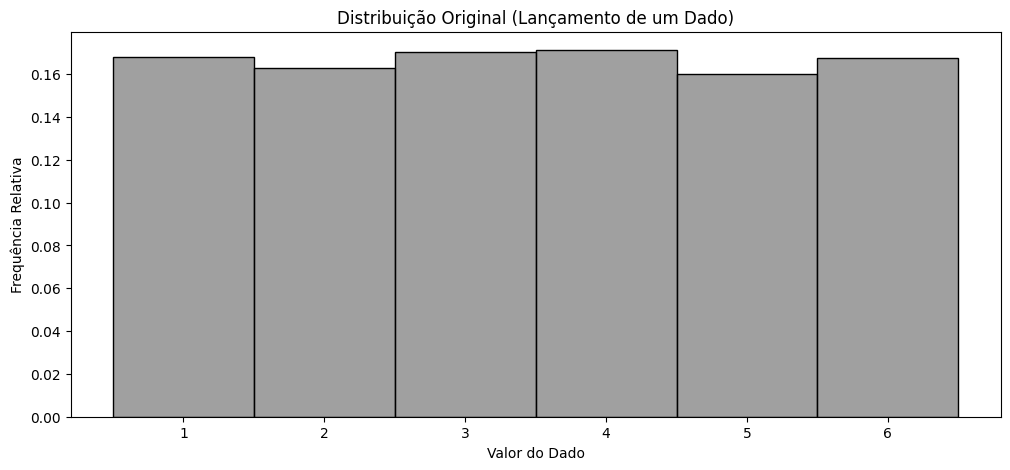

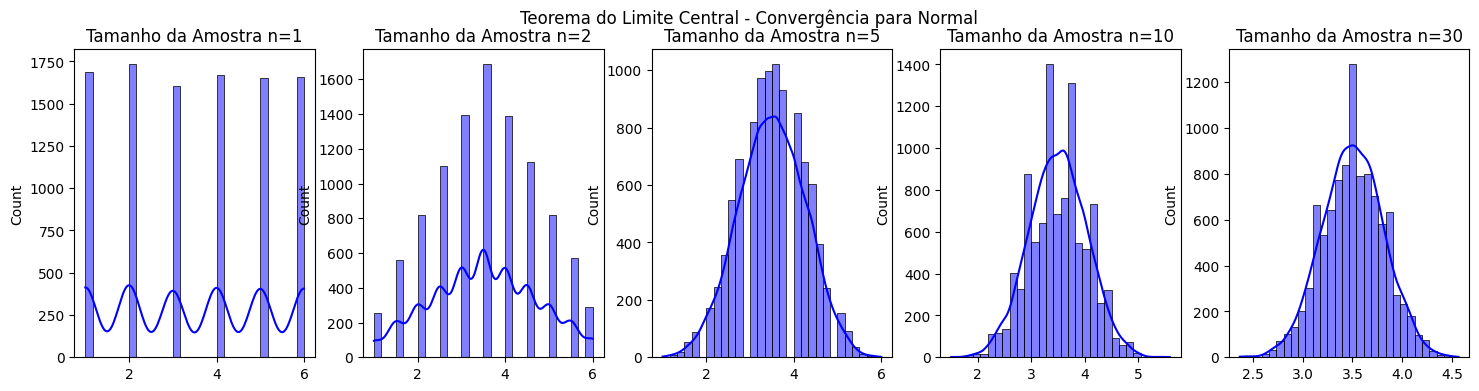

In [74]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Parâmetros
num_replications = 10000  # Número de amostras geradas
sample_sizes = [1, 2, 5, 10, 30]  # Tamanhos das amostras

# Simulação do lançamento de um dado (distribuição discreta uniforme de 1 a 6)
dados = np.random.randint(1, 7, num_replications)

# Plotando a distribuição original do lançamento de um único dado
plt.figure(figsize=(12, 5))
sns.histplot(dados, bins=np.arange(1, 8)-0.5, kde=False, stat="density", color="gray", edgecolor="black")
plt.xticks(range(1, 7))
plt.title("Distribuição Original (Lançamento de um Dado)")
plt.xlabel("Valor do Dado")
plt.ylabel("Frequência Relativa")
plt.show()

# Criando gráficos para diferentes tamanhos de amostra
fig, axes = plt.subplots(1, len(sample_sizes), figsize=(18, 4))

for i, n in enumerate(sample_sizes):
    sample_means = np.mean(np.random.randint(1, 7, (num_replications, n)), axis=1)
    sns.histplot(sample_means, bins=30, kde=True, ax=axes[i], color="blue")
    axes[i].set_title(f"Tamanho da Amostra n={n}")

plt.suptitle("Teorema do Limite Central - Convergência para Normal")
plt.show()



## Variáveis aleatórias bidimensionais: Caso discreto


**Definição:** $ p_{_{X,Y}}(x,y) $ representa a **função de massa de probabilidade conjunta** de duas variáveis aleatórias discretas $ X $ e $ Y $.


### Propriedades:
- $p_{_{X,Y}}(x,y) \geq 0$, para todo $(x,y)$.
- $\displaystyle\sum_{x_i \in R_x} \displaystyle\sum_{y_i \in R_y} p_{_{X,Y}}(x_i, y_i) = 1$.



##### Exemplo (Processo de Inspeção de Qualidade)
- $X$: Passa (1) ou Falha (0) no 1º teste.
- $Y$: Passa (1) ou Falha (0) no 2º teste.

Tabela de f.m.p. conjunta $p_{_{X,Y}}(x,y)$:

$
\begin{array}{c|ccc}
X \setminus Y & 0 & 1  \\ \hline
0 & 0.1 & 0.2 \\
1 & 0.2 & 0.5  \\
\end{array}
$


### Distribuições marginais

- **Caso Discreto:**
  - Probabilidade marginal de $ X $:

    $
    p_{_X}(x) = \displaystyle\sum_{y \in R_y} p_{_{X,Y}}(x,y)
    $

  - Probabilidade marginal de $ Y $:

    $
    p_{_Y}(y) = \displaystyle\sum_{x \in R_x} p_{_{X,Y}}(x,y)
    $



##### Exemplo (Distribuições Marginais)
Usando a f.m.p. conjunta do exemplo de inspeção de qualidade

Tabela de f.m.p. conjunta $p_{_{X,Y}}(x,y)$:

$
\begin{array}{c|ccc}
X \setminus Y & 0 & 1  \\ \hline
0 & 0.1 & 0.2 \\
1 & 0.2 & 0.5  \\
\end{array}
$

encontramos as marginais:

- $p_X(0) = 0.3$, $p_X(1) = 0.7$
- $p_Y(0) = 0.3$, $p_Y(1) = 0.7$


Na Tabela:

$
\begin{array}{c|cc|c}
X \setminus Y & 0 & 1 & p_X(x) \\ \hline
0 & 0.1 & 0.2 & 0.3 \\
1 & 0.2 & 0.5 & 0.7 \\ \hline
p_Y(y) & 0.3 & 0.7 & 1.0
\end{array}
$


## Variáveis aleatórias bidimensionais: Caso contínuo


- A f.d.p. conjunta de $X$ e $Y$ é $f_{_{X,Y}}(x,y)$, que deve satisfazer

  - $f_{_{X,Y}}(x,y) \geq 0$ para todo $(x,y)$

  - $\displaystyle \int_{-\infty}^{\infty} \int_{-\infty}^{\infty} f_{_{X,Y}}(x,y) \, dy \, dx = 1$


**Definição:** A função de distribuição acumulada $F_{_{X,Y}}(x,y) = P(X \leq x, Y \leq y)$ satisfaz:

$$F_{_{X,Y}}(x,y) = P(X \leq x, Y \leq y) = \int_{-\infty}^{x} \int_{-\infty}^{y} f_{_{X,Y}}(u,v) \, dv \, du$$



### Propriedades:

- $f_{_{X,Y}}(x,y) = \displaystyle\frac{\partial^2}{\partial x \partial y} F_{_{X,Y}}(x,y)$
- Probabilidade conjunta $P(a \leq X \leq b, c \leq Y \leq d) = \displaystyle \int_{a}^{b} \int_{c}^{d} f_{_{X,Y}}(x,y) \, dy \, dx$


##### Exemplo (Empuxo e Taxa de Mistura)

Dada a função de densidade de probabilidade conjunta de X (empuxo) e Y (taxa de mistura)

$
f_{_{X,Y}}(x,y) = 2(x + y - 2xy) \text{,  para } 0 \leq x \leq 1, 0 \leq y \leq 1.
$

1. Verifique que é uma função densidade de probabilidade.

2. Calcule $P(0 \leq X \leq 0.5, 0.5 \leq Y \leq 1)$. Resolva usando o WolframAlpha (https://www.wolframalpha.com/) e numericamente usando o pacote scipy.




Resolução:

A função $ f_{_{X,Y}}(x,y) $ deve satisfazer $
\displaystyle\int_0^1 \displaystyle\int_0^1 f_{_{X,Y}}(x,y) \,dx\,dy = 1.
$

Substituindo $ f_{_{X,Y}}(x,y) $, temos $
\displaystyle\int_0^1 \displaystyle\int_0^1 2(x + y - 2xy) \,dx\,dy.
$

Calculando a integral interna, temos

$
2 \displaystyle\int_0^1 x \,dx + 2 \displaystyle\int_0^1 y \,dx - 4 \displaystyle\int_0^1 xy \,dx.
$  


$
2 \left[ \frac{x^2}{2} \right]\Big|_0^1 + 2y \left[ x \right]\Big|_0^1 - 4y \left[ \frac{x^2}{2} \right]\Big|_0^1.
$

$
2 \left( \frac{1}{2} \right) + 2y(1) - 4y \left( \frac{1}{2} \right).
$

$
1 + 2y - 2y = 1.
$

Agora, integrando em $ y $:

$
\displaystyle\int_0^1 1 \,dy = [y]\Big|_0^1 = 1.
$

Portanto, $ f_{_{X,Y}}(x,y) $ é uma função densidade de probabilidade.


2. Calcule $P(0 \leq X \leq 0.5, 0.5 \leq Y \leq 1)$. Resolva usando o WolframAlpha (https://www.wolframalpha.com/).

Para calcular usando o WolframAlpha, podemos escrever

Integrate[Integrate[2 (x + y - 2 x y), {y, 0.5, 1}], {x, 0, 0.5}]  

que resulta em 0.3125.

In [75]:
# Cálculo da integral numericamente usando o pacote scipy

import scipy.integrate as spi

# Definição da função de densidade conjunta
def f_xy(x, y):
    return 2 * (x + y - 2 * x * y)

# Limites da integração
x_min, x_max = 0, 0.5
y_min, y_max = 0.5, 1

# Cálculo da integral dupla
probabilidade, erro = spi.dblquad(f_xy, x_min, x_max, lambda x: y_min, lambda x: y_max)

print(f"Probabilidade: {probabilidade:.5f}")


Probabilidade: 0.31250



### Densidades Marginais


- **Caso Contínuo**
  - Densidade marginal de $ X $:
$f_{_X}(x) = \displaystyle\int_{R_y} f_{_{X,Y}}(x,y) \, dy$

  - Densidade marginal de $ Y $:
$f_{_Y}(y) = \displaystyle\int_{R_x} f_{_{X,Y}}(x,y) \, dx$




## Independência Probabilística
$X$ e $Y$ são independentes se:

$
p_{_{X,Y}}(x,y) = p_X(x) p_Y(y), \quad \forall x \in R_X, y \in R_Y.
$

Ou, no caso contínuo:

$
f_{_{X,Y}}(x,y) = f_X(x) f_Y(y), \quad \forall x, y.
$


##### Exemplo: Independência Probabilística

Considere as variáveis aleatórias $ X $ e $ Y $ cuja função de massa de probabilidade conjunta é dada por:

$\begin{array}{c|cc|c}
X \setminus Y & 0 & 1 & p_X(x) \\
\hline
0 & 0.2 & 0.2 & 0.4 \\
1 & 0.3 & 0.3 & 0.6 \\
\hline
p_Y(y) & 0.5 & 0.5 & 1
\end{array}$


Para verificar se existe independência probabilística, vamos checar se

$$
p_{_{X,Y}}(x,y) = p_X(x) p_Y(y).
$$

para todo par $(x,y)$.


$
\begin{array}{c|cc|c}
X \setminus Y & 0 & 1 & p_X(x) \\
\hline
0 & 0.4 \times 0.5 = 0.2 & 0.4 \times 0.5 = 0.2 & 0.4 \\
1 & 0.6 \times 0.5 = 0.3 & 0.6 \times 0.5 = 0.3 & 0.6 \\
\hline
p_Y(y) & 0.5 & 0.5 & 1
\end{array}
$





Como a distribuição conjunta é o produto das marginais, $ X $ e $ Y $ são independentes.



### Esperança, Covariância e Correlação:

##### Valor esperado


$E(h(X,Y)) =\displaystyle \sum_{x \in R_x} \sum_{y \in R_y} h(x,y) p_{_{X,Y}}(x,y)$ (discreto)


$
E[h(X,Y)] = \displaystyle \int_{-\infty}^{\infty} \int_{-\infty}^{\infty} h(x,y) f_{_{X,Y}}(x,y) \, dx \, dy
$ (contínuo)



##### Covariância

$\sigma_{_{XY}} = E(XY) - E(X)E(Y)$





##### Correlação

A correlação entre duas variáveis aleatórias $X$ e $Y$ mede a intensidade e a direção da relação linear entre elas. Ela é definida como:

$
\rho_{X,Y} = \displaystyle\frac{\text{Cov}(X,Y)}{\sigma_X \sigma_Y} =\displaystyle\frac{\sigma_{XY}}{\sigma_X \sigma_Y}  
$

onde:

- $\text{Cov}(X,Y)$ é a covariância entre $X$ e $Y$, dada por:

  $
  \text{Cov}(X,Y) = E[XY] - E[X]E[Y]
  $

- $\sigma_X$ e $\sigma_Y$ são os desvios padrão de $X$ e $Y$:

  $
  \sigma_X = \sqrt{\text{Var}(X)}, \quad \sigma_Y = \sqrt{\text{Var}(Y)}
  $

A correlação $\rho_{X,Y}$ varia no intervalo $[-1,1]$:

- $\rho_{X,Y} = 1$ indica correlação perfeita positiva entre $X$ e $Y$.
- $\rho_{X,Y} = -1$ indica correlação perfeita negativa entre $X$ e $Y$.
- $\rho_{X,Y} = 0$ sugere ausência de relação linear entre $X$ e $Y$.




##### Exemplo: Cálculo da correlação com uma f.m.p. conjunta

Considere as variáveis $X$ e $Y$, representando os resultados de um processo de inspeção de qualidade. A função de massa de probabilidade (f.m.p.) conjunta é dada pela tabela:

$
\begin{array}{c|cc}
X \setminus Y & 0 & 1 \\
\hline
0 & 0.1 & 0.2 \\
1 & 0.2 & 0.5 \\
\end{array}
$

**Passo 1: Cálculo das Esperanças $E[X]$ e $E[Y]$**

A esperança matemática de $X$ é:

$
E[X] = \sum_{x} x p_X(x)
$

As probabilidades marginais de $X$ são:

$
p_X(0) = 0.3, \quad p_X(1) = 0.7
$

Portanto:

$
E[X] = 0 \cdot 0.3 + 1 \cdot 0.7 = 0.7
$

Analogamente, para $Y$:

$
p_Y(0) = 0.3, \quad p_Y(1) = 0.7
$

$
E[Y] = 0 \cdot 0.3 + 1 \cdot 0.7 = 0.7
$

**Passo 2: Cálculo de $E[XY]$**

$
E[XY] = \displaystyle\sum_{x} \sum_{y} x y p_{_{X,Y}}(x,y)
$

$
E[XY] = (0 \cdot 0 \cdot 0.1) + (0 \cdot 1 \cdot 0.2) + (1 \cdot 0 \cdot 0.2) + (1 \cdot 1 \cdot 0.5)
$

$
E[XY] = 0 + 0 + 0 + 0.5 = 0.5
$

**Passo 3: Cálculo da Covariância**

$
\text{Cov}(X,Y) = E[XY] - E[X]E[Y]
$

$
\text{Cov}(X,Y) = 0.5 - (0.7 \times 0.7) = 0.5 - 0.49 = 0.01
$

**Passo 4: Cálculo das Variâncias e da Correlação**

$
\text{Var}(X) = E[X^2] - (E[X])^2
$

$
E[X^2] =  \displaystyle\sum_{x} x^2 p_X(x) = (0^2 \cdot 0.3) + (1^2 \cdot 0.7) = 0 + 0.7 = 0.7
$

$
\text{Var}(X) = 0.7 - (0.7)^2 = 0.7 - 0.49 = 0.21
$

Analogamente, $\text{Var}(Y) = 0.21$.

Os desvios padrão são:

$
\sigma_X = \sqrt{0.21} \approx 0.458, \quad \sigma_Y = \sqrt{0.21} \approx 0.458
$

Finalmente, a correlação é:

$
\rho_{X,Y} = \displaystyle\frac{0.01}{0.458 \times 0.458} = \displaystyle\frac{0.01}{0.21} \approx 0.048
$

Portanto, $\rho_{X,Y} \approx 0.048$ indica uma correlação fraca entre $X$ e $Y$, o que indica associação linear muito fraca entre elas.

## Propriedades da Esperança, Variância e Covariância

### 1. **Propriedades do Valor Esperado**
Sejam $ X $ e $ Y $ variáveis aleatórias e $ a, b $ constantes:

1. $
   E(aX + bY) = aE(X) + bE(Y)
   $ (linearidade)
2. $
   E(c) = c.
   $
3. $
   \text{Se } X \text{ e } Y \text{ são independentes, então } E(XY) = E(X)E(Y).
   $

### 2. **Propriedades da Variância**
A variância de uma variável aleatória $ X $ é definida como:
   $
   \text{Var}(X) = E((X - E(X))^2) = E(X^2) - (E(X))^2.
   $
Propriedades:
1. $
   \text{Var}(c) = 0
   $ (variância de uma constante)
2. $
   \text{Var}(aX + b) = a^2 \text{Var}(X)
   $ (variância de uma transformação afim)
3. $
   \text{Se } X \text{ e } Y \text{ são independentes, então }
   \text{Var}(X + Y) = \text{Var}(X) + \text{Var}(Y).
   $

### 3. **Propriedades da Covariância**
A covariância entre duas variáveis $ X $ e $ Y $ é dada por:
   $
   \sigma_{_{XY}} = \text{Cov}(X, Y) = E(XY) - E(X)E(Y).
   $
Propriedades:
1.  $
   \text{Cov}(X, Y) = \text{Cov}(Y, X)
   $ (simetria)
2. $
   \text{Cov}(X, c) = 0
   $ (covariância com uma constante)
3. $
   \text{Cov}(aX + b, Y) = a \text{Cov}(X, Y)
   $ (linearidade)
4.  $
   \text{Var}(X) = \text{Cov}(X, X).
   $
5. Se $ X $ e $ Y $ são independentes, então
   $
   \text{Cov}(X, Y) = 0.
   $
